# Lab 5a SYS 5581
# Bethany Amanuel bes5ve  

In [23]:
'''1) Imports and Reproducibility'''

import copy
import math
import os
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset

import torchvision
import torchvision.transforms as T

from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

SEED = 5581
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
'''2) Configuration'''

@dataclass
class Config:
    batch_size: int = 128
    num_workers: int = 2
    clean_epochs: int = 10
    poisoned_epochs: int = 10
    targeted_epochs: int = 10
    learning_rate: float = 1e-3
    weight_decay: float = 5e-4
    poison_rates: Tuple[float, ...] = (0.01, 0.05, 0.10, 0.20)

    '''Runtime controls'''
    use_subset: bool = False           # Set True for fast CPU testing, False for final run
    train_subset_size: int = 12000
    test_subset_size: int = 2000

    '''Targeted attack controls'''
    target_true_class: int = 0         # airplane by default
    target_desired_class: int = 2      # bird by default
    num_poisons: int = 25
    poison_eps: float = 8/255
    poison_steps: int = 150
    poison_step_size: float = 1/255
    feature_collision_beta: float = 0.1

CFG = Config()
CFG

Config(batch_size=128, num_workers=2, clean_epochs=10, poisoned_epochs=10, targeted_epochs=10, learning_rate=0.001, weight_decay=0.0005, poison_rates=(0.01, 0.05, 0.1, 0.2), use_subset=False, train_subset_size=12000, test_subset_size=2000, target_true_class=0, target_desired_class=2, num_poisons=25, poison_eps=0.03137254901960784, poison_steps=150, poison_step_size=0.00392156862745098, feature_collision_beta=0.1)

## 1. Description of Victim Model

The code below loads CIFAR-10, defines a compact CNN victim model, and trains a clean baseline that will be reused for the poisoning experiments.

In [3]:
'''3) Dataset Loading (CIFAR-10)'''

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std),
])

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std),
])

raw_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
raw_test = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

class_names = raw_train.classes
print(class_names)

if CFG.use_subset:
    train_idx = np.random.choice(len(raw_train), size=CFG.train_subset_size, replace=False)
    test_idx = np.random.choice(len(raw_test), size=CFG.test_subset_size, replace=False)
    train_set = Subset(raw_train, train_idx)
    test_set = Subset(raw_test, test_idx)
else:
    train_set = raw_train
    test_set = raw_test

train_loader = DataLoader(train_set, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=True)

len(train_set), len(test_set)

100%|██████████| 170M/170M [00:04<00:00, 38.3MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


(50000, 10000)

In [4]:
'''4) Victim Model Definition'''

class SmallCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

    def embed(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return x

def make_model():
    return SmallCNN().to(device)

model = make_model()
print(model)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128

In [5]:
'''5) Training / Evaluation Utilities'''

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_y, all_pred = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        if criterion is not None:
            running_loss += criterion(logits, y).item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        all_y.append(y.cpu().numpy())
        all_pred.append(preds.cpu().numpy())

    metrics = {
        "loss": running_loss / total if criterion is not None else None,
        "accuracy": correct / total,
        "y_true": np.concatenate(all_y),
        "y_pred": np.concatenate(all_pred),
    }
    return metrics

def fit_model(model, train_loader, test_loader, epochs, lr, weight_decay, verbose=True):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        te = evaluate(model, test_loader, criterion)
        history.append({
            "epoch": epoch,
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "test_loss": te["loss"],
            "test_acc": te["accuracy"],
        })
        if verbose:
            print(f"Epoch {epoch:02d}/{epochs} | train_acc={tr_acc:.4f} | test_acc={te['accuracy']:.4f}")
    return pd.DataFrame(history)

In [6]:
'''6) Train Clean Baseline'''

clean_model = make_model()
clean_history = fit_model(
    clean_model,
    train_loader,
    test_loader,
    epochs=CFG.clean_epochs,
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

clean_metrics = evaluate(clean_model, test_loader, nn.CrossEntropyLoss())
clean_baseline_acc = clean_metrics["accuracy"]
print("Baseline clean accuracy:", round(clean_baseline_acc, 4))
clean_history.tail()

Epoch 01/10 | train_acc=0.5143 | test_acc=0.5984
Epoch 02/10 | train_acc=0.6667 | test_acc=0.6576
Epoch 03/10 | train_acc=0.7255 | test_acc=0.6850
Epoch 04/10 | train_acc=0.7631 | test_acc=0.6961
Epoch 05/10 | train_acc=0.7971 | test_acc=0.6879
Epoch 06/10 | train_acc=0.8191 | test_acc=0.7411
Epoch 07/10 | train_acc=0.8396 | test_acc=0.7304
Epoch 08/10 | train_acc=0.8533 | test_acc=0.8114
Epoch 09/10 | train_acc=0.8664 | test_acc=0.7885
Epoch 10/10 | train_acc=0.8769 | test_acc=0.7345
Baseline clean accuracy: 0.7345


,epoch,train_loss,train_acc,test_loss,test_acc
5,6,0.523260,0.81912,0.754122,0.7411
6,7,0.468705,0.83962,0.836758,0.7304
7,8,0.429510,0.85328,0.566870,0.8114
8,9,0.389793,0.86644,0.625211,0.7885
9,10,0.357926,0.87686,0.863036,0.7345


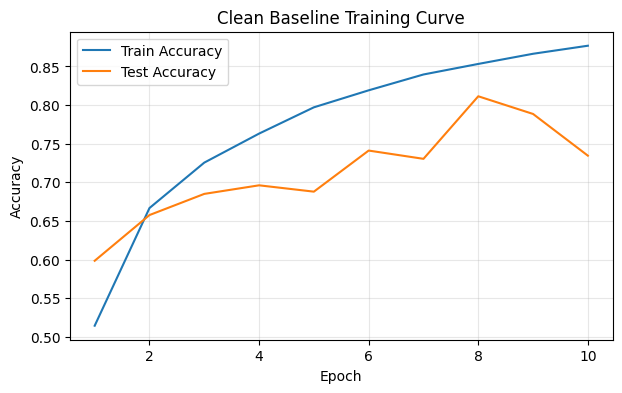

              precision    recall  f1-score   support

    airplane       0.69      0.89      0.77      1000
  automobile       0.96      0.80      0.87      1000
        bird       0.51      0.88      0.64      1000
         cat       0.91      0.25      0.40      1000
        deer       0.52      0.89      0.66      1000
         dog       0.81      0.62      0.70      1000
        frog       0.79      0.87      0.83      1000
       horse       0.94      0.57      0.71      1000
        ship       0.94      0.80      0.86      1000
       truck       0.93      0.78      0.85      1000

    accuracy                           0.73     10000
   macro avg       0.80      0.73      0.73     10000
weighted avg       0.80      0.73      0.73     10000



In [7]:
'''7) Baseline Curves and Metrics'''

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(clean_history["epoch"], clean_history["train_acc"], label="Train Accuracy")
ax.plot(clean_history["epoch"], clean_history["test_acc"], label="Test Accuracy")
ax.set_title("Clean Baseline Training Curve")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

print(classification_report(clean_metrics["y_true"], clean_metrics["y_pred"], target_names=class_names))

## 2. Indiscriminate Attack Section

The indiscriminate attack implemented below is a label-flipping attack on the CIFAR-10 training set. This is a classic availability attack because the goal is not to target one specific image, but to degrade the victim model's overall performance.

In [8]:
'''8) Helper to Materialize Entire Dataset into Tensors'''

def dataset_to_tensors(dataset):
    xs, ys = [], []
    for x, y in dataset:
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.tensor(ys, dtype=torch.long)

train_x, train_y = dataset_to_tensors(train_set)
test_x, test_y = dataset_to_tensors(test_set)

print(train_x.shape, train_y.shape, test_x.shape, test_y.shape)

torch.Size([50000, 3, 32, 32]) torch.Size([50000]) torch.Size([10000, 3, 32, 32]) torch.Size([10000])


In [9]:
'''9) Indiscriminate Label-Flipping Attack'''

def flip_labels_indiscriminate(labels: torch.Tensor, poison_rate: float, num_classes: int = 10):
    poisoned_labels = labels.clone()
    n = len(labels)
    num_poison = int(poison_rate * n)
    poison_idx = np.random.choice(n, size=num_poison, replace=False)

    for idx in poison_idx:
        original = poisoned_labels[idx].item()
        # Deliberately flip to a wrong class. Random wrong-class flipping is simple and effective.
        choices = [c for c in range(num_classes) if c != original]
        poisoned_labels[idx] = random.choice(choices)

    return poisoned_labels, poison_idx

def make_loader_from_tensors(x_tensor, y_tensor, batch_size, shuffle=True):
    ds = TensorDataset(x_tensor, y_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True)

indiscriminate_results = []

for rate in CFG.poison_rates:
    poison_y, poison_idx = flip_labels_indiscriminate(train_y, rate, num_classes=10)
    poisoned_train_loader = make_loader_from_tensors(train_x, poison_y, CFG.batch_size, shuffle=True)

    model = make_model()
    hist = fit_model(
        model,
        poisoned_train_loader,
        test_loader,
        epochs=CFG.poisoned_epochs,
        lr=CFG.learning_rate,
        weight_decay=CFG.weight_decay,
        verbose=False,
    )
    eval_metrics = evaluate(model, test_loader, nn.CrossEntropyLoss())

    indiscriminate_results.append({
        "poison_rate": rate,
        "num_poisoned_samples": len(poison_idx),
        "test_accuracy": eval_metrics["accuracy"],
        "accuracy_drop_vs_clean": clean_baseline_acc - eval_metrics["accuracy"],
    })

    print(f"Finished poison rate {rate:.0%} | acc={eval_metrics['accuracy']:.4f}")

indiscriminate_df = pd.DataFrame(indiscriminate_results)
indiscriminate_df

Finished poison rate 1% | acc=0.7739
Finished poison rate 5% | acc=0.7689
Finished poison rate 10% | acc=0.7653
Finished poison rate 20% | acc=0.7595


,poison_rate,num_poisoned_samples,test_accuracy,accuracy_drop_vs_clean
0,0.01,500,0.7739,-0.0394
1,0.05,2500,0.7689,-0.0344
2,0.10,5000,0.7653,-0.0308
3,0.20,10000,0.7595,-0.0250


,poison_rate,num_poisoned_samples,test_accuracy,accuracy_drop_vs_clean
0,1%,500,0.7739,-0.0394
1,5%,2500,0.7689,-0.0344
2,10%,5000,0.7653,-0.0308
3,20%,10000,0.7595,-0.0250


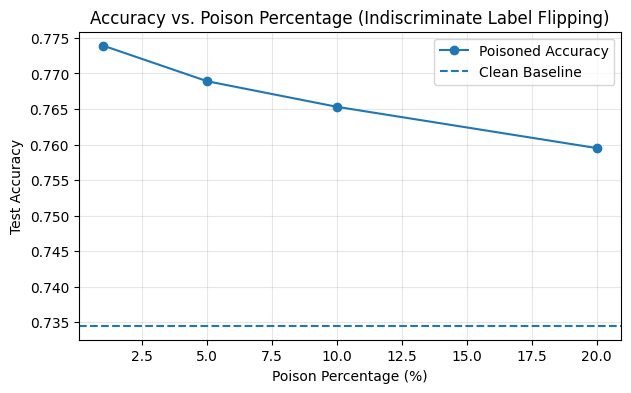

In [10]:
'''10) Indiscriminate Results Table + Curve'''

display(indiscriminate_df.style.format({
    "poison_rate": "{:.0%}",
    "test_accuracy": "{:.4f}",
    "accuracy_drop_vs_clean": "{:.4f}",
}))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(indiscriminate_df["poison_rate"] * 100, indiscriminate_df["test_accuracy"], marker="o", label="Poisoned Accuracy")
ax.axhline(clean_baseline_acc, linestyle="--", label="Clean Baseline")
ax.set_title("Accuracy vs. Poison Percentage (Indiscriminate Label Flipping)")
ax.set_xlabel("Poison Percentage (%)")
ax.set_ylabel("Test Accuracy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 3. Targeted Attack Section

The implementation below uses a gradient-based clean-label targeted poisoning attack inspired by the feature-collision idea. The attacker selects:
1. one target test image to flip,
2. one desired incorrect class,
3. a small set of training images from the desired class,
4. gradient steps that make those poison images move toward the target in feature space while staying visually close to their original appearance.

In [11]:
'''11) Target Selection Utilities'''

def get_dataset_indices_by_label(labels_tensor, label):
    return np.where(labels_tensor.numpy() == label)[0]

# Pick one target from the test set
test_indices_true = get_dataset_indices_by_label(test_y, CFG.target_true_class)
target_test_index = int(test_indices_true[0])

target_x = test_x[target_test_index:target_test_index+1].to(device)
target_y = test_y[target_test_index].item()

# Pick candidate base images from the desired target class in the training set
train_indices_desired = get_dataset_indices_by_label(train_y, CFG.target_desired_class)
base_indices = train_indices_desired[:CFG.num_poisons]

print("Target true class:", target_y, class_names[target_y])
print("Desired misclassification class:", CFG.target_desired_class, class_names[CFG.target_desired_class])
print("Target test index:", target_test_index)
print("Number of poison bases:", len(base_indices))

Target true class: 0 airplane
Desired misclassification class: 2 bird
Target test index: 3
Number of poison bases: 25


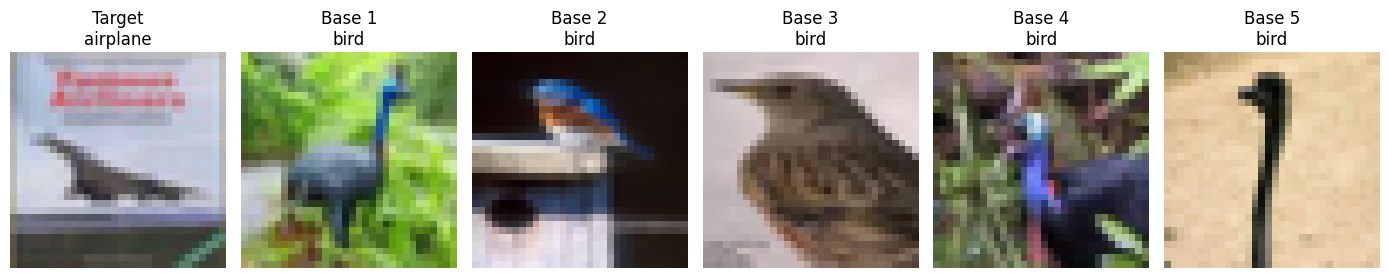

In [12]:
''' 12) Visualize Target and Example Bases '''

def unnormalize(x):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(x.cpu() * std_t + mean_t, 0, 1)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(np.transpose(unnormalize(target_x[0]).numpy(), (1, 2, 0)))
axes[0].set_title(f"Target\n{class_names[target_y]}")
axes[0].axis("off")

for i in range(5):
    img = train_x[base_indices[i]]
    axes[i+1].imshow(np.transpose(unnormalize(img).numpy(), (1, 2, 0)))
    axes[i+1].set_title(f"Base {i+1}\n{class_names[CFG.target_desired_class]}")
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

In [13]:
''' 13) Gradient-Based Poison Crafting (Feature Collision)'''

def craft_feature_collision_poisons(
    surrogate_model: nn.Module,
    train_x: torch.Tensor,
    base_indices: np.ndarray,
    target_x: torch.Tensor,
    eps: float,
    steps: int,
    step_size: float,
    beta: float,
):
    surrogate_model.eval()
    crafted = []

    with torch.no_grad():
        target_feat = surrogate_model.embed(target_x).detach()

    for idx in base_indices:
        base = train_x[idx:idx+1].to(device)
        poison = base.clone().detach().requires_grad_(True)

        for _ in range(steps):
            poison_feat = surrogate_model.embed(poison)
            feature_loss = F.mse_loss(poison_feat, target_feat)
            image_loss = F.mse_loss(poison, base)
            loss = feature_loss + beta * image_loss

            loss.backward()

            with torch.no_grad():
                # Descend on feature collision objective
                poison -= step_size * poison.grad.sign()

                # Project into epsilon-ball around the original base image
                delta = torch.clamp(poison - base, min=-eps, max=eps)
                poison[:] = torch.clamp(base + delta, (0 - torch.tensor(mean, device=device).view(1,3,1,1)) / torch.tensor(std, device=device).view(1,3,1,1),
                                        (1 - torch.tensor(mean, device=device).view(1,3,1,1)) / torch.tensor(std, device=device).view(1,3,1,1))
            poison.grad.zero_()

        crafted.append(poison.detach().cpu())

    return torch.cat(crafted, dim=0)

surrogate = copy.deepcopy(clean_model).to(device)
crafted_poisons = craft_feature_collision_poisons(
    surrogate_model=surrogate,
    train_x=train_x,
    base_indices=base_indices,
    target_x=target_x,
    eps=CFG.poison_eps,
    steps=CFG.poison_steps,
    step_size=CFG.poison_step_size,
    beta=CFG.feature_collision_beta,
)

print("Crafted poisons shape:", crafted_poisons.shape)

Crafted poisons shape: torch.Size([25, 3, 32, 32])


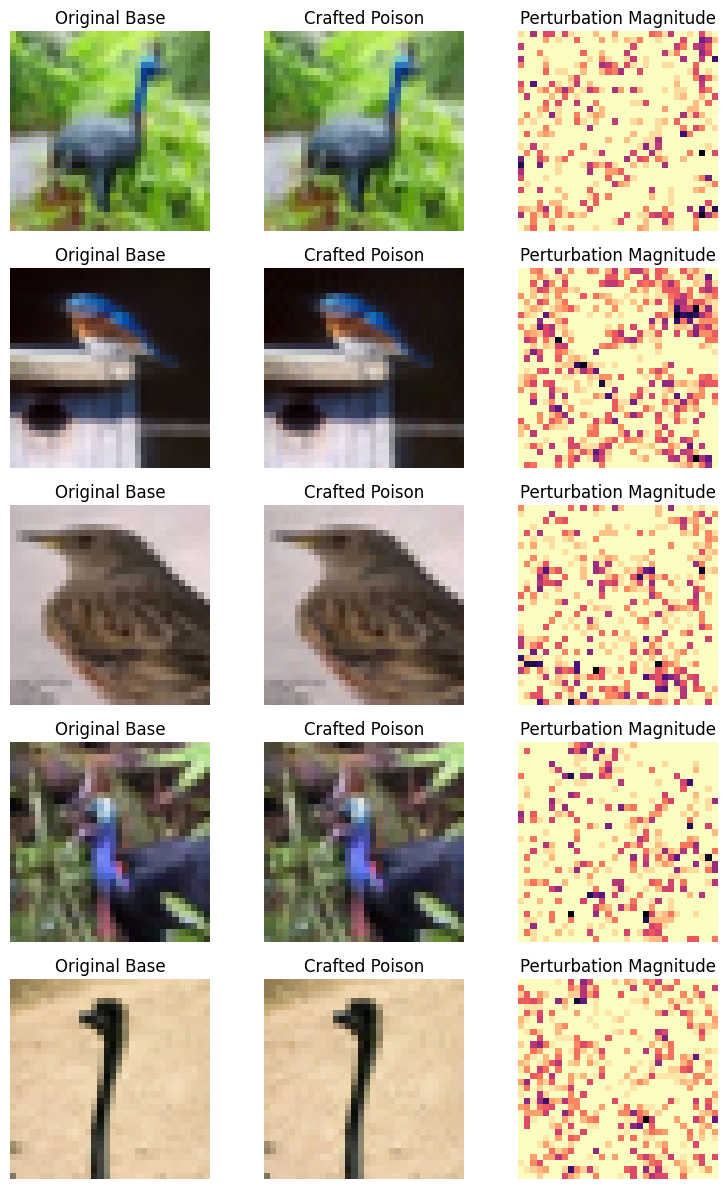

In [14]:
'''14) Visualize Poisons and Perturbations'''

num_show = min(5, len(base_indices))
fig, axes = plt.subplots(num_show, 3, figsize=(8, 2.4 * num_show))

for row in range(num_show):
    base = train_x[base_indices[row]]
    poison = crafted_poisons[row]
    delta = poison - base

    axes[row, 0].imshow(np.transpose(unnormalize(base).numpy(), (1, 2, 0)))
    axes[row, 0].set_title("Original Base")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(np.transpose(unnormalize(poison).numpy(), (1, 2, 0)))
    axes[row, 1].set_title("Crafted Poison")
    axes[row, 1].axis("off")

    delta_vis = delta.abs().mean(dim=0).numpy()
    axes[row, 2].imshow(delta_vis, cmap="magma")
    axes[row, 2].set_title("Perturbation Magnitude")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [15]:
'''15) Build Poisoned Training Set for Targeted Attack'''

targeted_train_x = train_x.clone()
targeted_train_y = train_y.clone()

# Replace chosen base samples with the "poisons", but keep labels unchanged (clean-label attack)
for pos, idx in enumerate(base_indices):
    targeted_train_x[idx] = crafted_poisons[pos]
    targeted_train_y[idx] = CFG.target_desired_class

targeted_loader = make_loader_from_tensors(targeted_train_x, targeted_train_y, CFG.batch_size, shuffle=True)

In [16]:
'''16) Retrain Victim on Targeted Poisoned Dataset'''

targeted_model = make_model()
targeted_history = fit_model(
    targeted_model,
    targeted_loader,
    test_loader,
    epochs=CFG.targeted_epochs,
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
    verbose=True,
)

targeted_metrics = evaluate(targeted_model, test_loader, nn.CrossEntropyLoss())
targeted_overall_acc = targeted_metrics["accuracy"]

with torch.no_grad():
    targeted_model.eval()
    logits = targeted_model(target_x)
    pred_class = logits.argmax(dim=1).item()
    pred_probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

target_success = int(pred_class == CFG.target_desired_class)

target_summary = pd.DataFrame([{
    "target_test_index": target_test_index,
    "true_class": class_names[target_y],
    "desired_class": class_names[CFG.target_desired_class],
    "predicted_class_after_poisoning": class_names[pred_class],
    "target_attack_success": bool(target_success),
    "num_poisons": CFG.num_poisons,
    "overall_test_accuracy_after_targeted_attack": targeted_overall_acc,
    "collateral_accuracy_drop_vs_clean": clean_baseline_acc - targeted_overall_acc,
}])

target_summary

Epoch 01/10 | train_acc=0.5112 | test_acc=0.5833
Epoch 02/10 | train_acc=0.6623 | test_acc=0.6863
Epoch 03/10 | train_acc=0.7236 | test_acc=0.7009
Epoch 04/10 | train_acc=0.7623 | test_acc=0.6762
Epoch 05/10 | train_acc=0.7901 | test_acc=0.7320
Epoch 06/10 | train_acc=0.8142 | test_acc=0.6609
Epoch 07/10 | train_acc=0.8325 | test_acc=0.7696
Epoch 08/10 | train_acc=0.8486 | test_acc=0.7927
Epoch 09/10 | train_acc=0.8603 | test_acc=0.7502
Epoch 10/10 | train_acc=0.8724 | test_acc=0.7468


,target_test_index,true_class,desired_class,predicted_class_after_poisoning,target_attack_success,num_poisons,overall_test_accuracy_after_targeted_attack,collateral_accuracy_drop_vs_clean
0,3,airplane,bird,ship,False,25,0.7468,-0.0123


,target_test_index,true_class,desired_class,predicted_class_after_poisoning,target_attack_success,num_poisons,overall_test_accuracy_after_targeted_attack,collateral_accuracy_drop_vs_clean
0,3,airplane,bird,ship,False,25,0.7468,-0.0123


,class,probability
8,ship,0.914251
0,airplane,0.063816
1,automobile,0.016525
2,bird,0.003046
9,truck,0.001019
6,frog,0.000628
3,cat,0.000555
7,horse,0.000082
4,deer,0.000040
5,dog,0.000039


/tmp/ipykernel_3760/2994249863.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(probs_df["class"], rotation=45, ha="right")


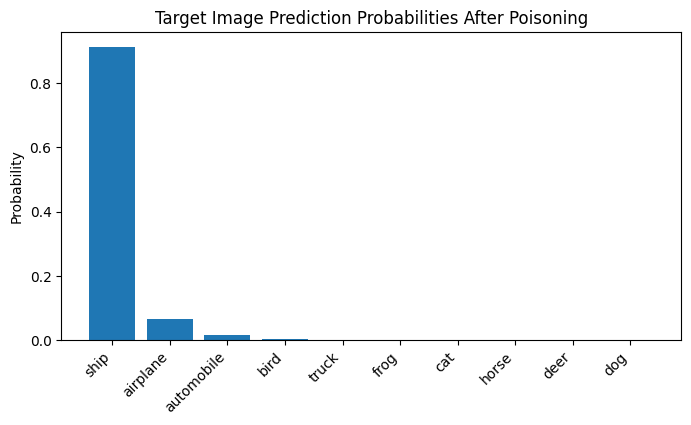

In [17]:
'''17) Inspect Target Prediction Probabilities'''

probs_df = pd.DataFrame({
    "class": class_names,
    "probability": pred_probs,
}).sort_values("probability", ascending=False)

display(target_summary)
display(probs_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(probs_df["class"], probs_df["probability"])
ax.set_title("Target Image Prediction Probabilities After Poisoning")
ax.set_ylabel("Probability")
ax.set_xticklabels(probs_df["class"], rotation=45, ha="right")
plt.show()

## 4. Stealth Analysis

The notebook uses two simple detectors:
1. Isolation Forest on penultimate-layer feature embeddings
2. Local Outlier Factor (LOF) on the same embeddings

These are intentionally simple baseline defenses. If they fail, that supports the claim that clean-label targeted poisons can hide inside the normal data distribution.

In [18]:
'''18) Feature Extraction for Stealth Detection'''

@torch.no_grad()
def extract_embeddings(model, x_tensor, batch_size=256):
    model.eval()
    feats = []
    for start in range(0, len(x_tensor), batch_size):
        xb = x_tensor[start:start+batch_size].to(device)
        emb = model.embed(xb).cpu().numpy()
        feats.append(emb)
    return np.concatenate(feats, axis=0)

# Use the surrogate / clean model as a feature extractor
clean_embeddings = extract_embeddings(clean_model, train_x)
poisoned_embeddings = extract_embeddings(clean_model, targeted_train_x)

poison_mask = np.zeros(len(train_x), dtype=int)
poison_mask[base_indices] = 1

print(clean_embeddings.shape, poisoned_embeddings.shape, poison_mask.sum())

(50000, 256) (50000, 256) 25


In [19]:
'''19) Isolation Forest Detection'''

scaler = StandardScaler()
scaled_feats = scaler.fit_transform(poisoned_embeddings)

iso = IsolationForest(
    n_estimators=200,
    contamination=max(CFG.num_poisons / len(train_x), 0.001),
    random_state=SEED,
)
iso_pred = iso.fit_predict(scaled_feats)    # -1 means outlier
iso_flag = (iso_pred == -1).astype(int)

iso_detection_rate = iso_flag[poison_mask == 1].mean()
iso_false_positive_rate = iso_flag[poison_mask == 0].mean()

print("Isolation Forest poison detection rate:", round(float(iso_detection_rate), 4))
print("Isolation Forest false positive rate:", round(float(iso_false_positive_rate), 4))

Isolation Forest poison detection rate: 0.0
Isolation Forest false positive rate: 0.001


In [20]:
'''20) Local Outlier Factor Detection'''

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=max(CFG.num_poisons / len(train_x), 0.001),
)
lof_pred = lof.fit_predict(scaled_feats)    # -1 means outlier
lof_flag = (lof_pred == -1).astype(int)

lof_detection_rate = lof_flag[poison_mask == 1].mean()
lof_false_positive_rate = lof_flag[poison_mask == 0].mean()

print("LOF poison detection rate:", round(float(lof_detection_rate), 4))
print("LOF false positive rate:", round(float(lof_false_positive_rate), 4))

LOF poison detection rate: 0.0
LOF false positive rate: 0.001


In [21]:
'''21) Detection Summary Table'''

stealth_df = pd.DataFrame([
    {
        "detector": "Isolation Forest",
        "poison_detection_rate": iso_detection_rate,
        "false_positive_rate": iso_false_positive_rate,
    },
    {
        "detector": "Local Outlier Factor",
        "poison_detection_rate": lof_detection_rate,
        "false_positive_rate": lof_false_positive_rate,
    },
])

display(stealth_df.style.format({
    "poison_detection_rate": "{:.4f}",
    "false_positive_rate": "{:.4f}",
}))

,detector,poison_detection_rate,false_positive_rate
0,Isolation Forest,0.0000,0.0010
1,Local Outlier Factor,0.0000,0.0010


In [22]:
'''22) Summary Values'''

summary_values = {
    "clean_baseline_accuracy": round(float(clean_baseline_acc), 4),
    "best_indiscriminate_accuracy": round(float(indiscriminate_df["test_accuracy"].min()), 4),
    "largest_accuracy_drop": round(float(indiscriminate_df["accuracy_drop_vs_clean"].max()), 4),
    "target_attack_success": bool(target_success),
    "targeted_attack_num_poisons": int(CFG.num_poisons),
    "targeted_overall_accuracy": round(float(targeted_overall_acc), 4),
    "targeted_collateral_drop": round(float(clean_baseline_acc - targeted_overall_acc), 4),
    "isolation_forest_detection_rate": round(float(iso_detection_rate), 4),
    "lof_detection_rate": round(float(lof_detection_rate), 4),
}
summary_values

{'clean_baseline_accuracy': 0.7345,
 'best_indiscriminate_accuracy': 0.7595,
 'largest_accuracy_drop': -0.025,
 'target_attack_success': False,
 'targeted_attack_num_poisons': 25,
 'targeted_overall_accuracy': 0.7468,
 'targeted_collateral_drop': -0.0123,
 'isolation_forest_detection_rate': 0.0,
 'lof_detection_rate': 0.0}